# 1. Email Spam Detection using TF-IDF + Logistic Regression
# Task: Classify emails as spam or ham using TF-IDF and logistic regression.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd

emails = [
    ("Win a FREE trip now!", "spam"),
    ("Please review the attached report", "ham"),
    ("Congratulations, you have won a lottery!", "spam"),
    ("Meeting scheduled at 10 AM tomorrow", "ham"),
    ("Free coupons waiting for you", "spam")
]

rows = []

for i, (text, label) in enumerate(emails):
    rows.append({"No": i, "email": text, "label": label})

email_df = pd.DataFrame(rows).set_index("No")

tfidf_vect = TfidfVectorizer()
X = tfidf_vect.fit_transform(email_df['email'])
y = email_df['label']

model = LogisticRegression()
model.fit(X, y)

test_email = ["Free lottery coupons"]
X_test = tfidf_vect.transform(test_email)
preds = model.predict(X_test)
print(test_email, '->', preds)



['Free lottery coupons'] -> ['spam']


# 2. News Classification using CountVectorizer
# Task: Classify news into politics or sports.

In [34]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
import pandas as pd

news_data = [
    ("The prime minister addressed the nation.", "politics"),
    ("The team won the cricket match yesterday.", "sports"),
    ("New laws were introduced in the parliament.", "politics"),
    ("Football tournament starts next week.", "sports"),
    ("Government announces new tax reforms.", "politics"),
    ("The opposition leader criticized the budget plan.", "politics"),
    ("India defeated Australia in the final match.", "sports"),
    ("The president signed the healthcare bill.", "politics"),
    ("Tennis champion wins her sixth Grand Slam title.", "sports"),
    ("Cabinet approves new education policy.", "politics"),
    ("The hockey league season begins tomorrow.", "sports"),
    ("Parliament passes the environmental protection act.", "politics"),
    ("The coach announced the final team squad.", "sports"),
    ("Elections to be held in five states next month.", "politics"),
    ("Star player scores a hat-trick in the football match.", "sports"),
    ("Supreme Court hears plea on a on recent ordinance.", "politics")]

rows = []

for i, (text, label) in enumerate(news_data):
    rows.append({"No": i, "news": text, "label": label})

email_df = pd.DataFrame(rows).set_index("No")

count_vect = CountVectorizer()
X = count_vect.fit_transform(email_df['news'])
y = email_df['label']

model = LogisticRegression()
model.fit(X, y)

test_email = ["Sachin Tendulkar is the man of the match"]
X_test = count_vect.transform(test_email)
preds = model.predict(X_test)
print(test_email, '->', preds)


['Sachin Tendulkar is the man of the match'] -> ['sports']


# 3. Product Review Sentiment using VADER
# Task: Perform sentiment analysis on product reviews.

In [35]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

reviews = [
    "Absolutely love this product, it works like a charm!",
    "Worst experience ever. Will never buy again.",
    "It's okay, not great but not bad either.",
    "Very satisfied with the quality!",
    "Disappointed. It stopped working in a week."
]

sia = SentimentIntensityAnalyzer()

for review in reviews:
    score = sia.polarity_scores(review)
    comp_score = score['compound']
    tot_score = 'Positive' if comp_score>0.5 else 'Negative' if comp_score<0.5 else 'Neutral'
    print(f'{review} -> {tot_score} with Compound Score: {comp_score}')


Absolutely love this product, it works like a charm! -> Positive with Compound Score: 0.8746
Worst experience ever. Will never buy again. -> Negative with Compound Score: -0.6249
It's okay, not great but not bad either. -> Negative with Compound Score: 0.4728
Very satisfied with the quality! -> Positive with Compound Score: 0.5244
Disappointed. It stopped working in a week. -> Negative with Compound Score: -0.6124


# 4. Topic Modeling on Articles using LDA
# Task: Extract 2 topics from a list of article contents.

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

docs = [
    "Deep learning models can process images and videos.",
    "Neural networks are at the core of deep learning.",
    "Global warming affects the climate and ecosystems.",
    "Carbon emissions cause climate change.",
    "Convolutional neural networks perform well in vision tasks."
]

count_vect = CountVectorizer()
count_matrix = count_vect.fit_transform(docs)
feature_names = count_vect.get_feature_names_out()

lda = LatentDirichletAllocation(n_components=2, random_state=10)
lda.fit(count_matrix)

for index, topics in enumerate(lda.components_):
    print('Topic #', index)
    print([feature_names[i] for i in topics.argsort()[-5:]])


Topic # 0
['warming', 'ecosystems', 'global', 'climate', 'the']
Topic # 1
['and', 'learning', 'deep', 'networks', 'neural']


#  5. Word Cloud for Movie Reviews
# Task: Visualize frequently used words in movie reviews.

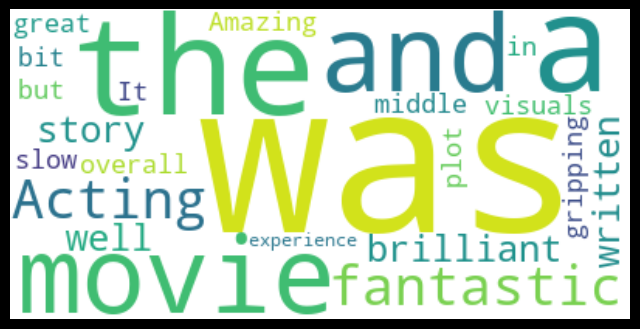

In [41]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt

movie_reviews = """
The movie was fantastic! Acting was brilliant and the story was well-written.
Amazing visuals and a gripping plot.
It was a bit slow in the middle, but overall a great movie experience.
"""

wordcld = WordCloud(width=400, height=200, stopwords='english', background_color='white').generate(movie_reviews)
plt.figure(figsize=[8,5])
plt.imshow(wordcld, interpolation='bilinear')
plt.axis(False)
plt.show()
